In [ ]:
# Purpose

This notebook performs PCA analysis, scree plot generation,
and box-plot visualization for socioeconomic class separability
using PRISMA hyperspectral data.




#Import Libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Import Dataset

In [ ]:
data = pd.read_csv ('path of csv file')

In [ ]:
print(data)

In [ ]:
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

In [ ]:
type(y)

numpy.ndarray

#Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

## Scree Plot

In [ ]:
from sklearn.decomposition import PCA
pca_all = PCA(n_components = 10)
X = pca_all.fit_transform(X)

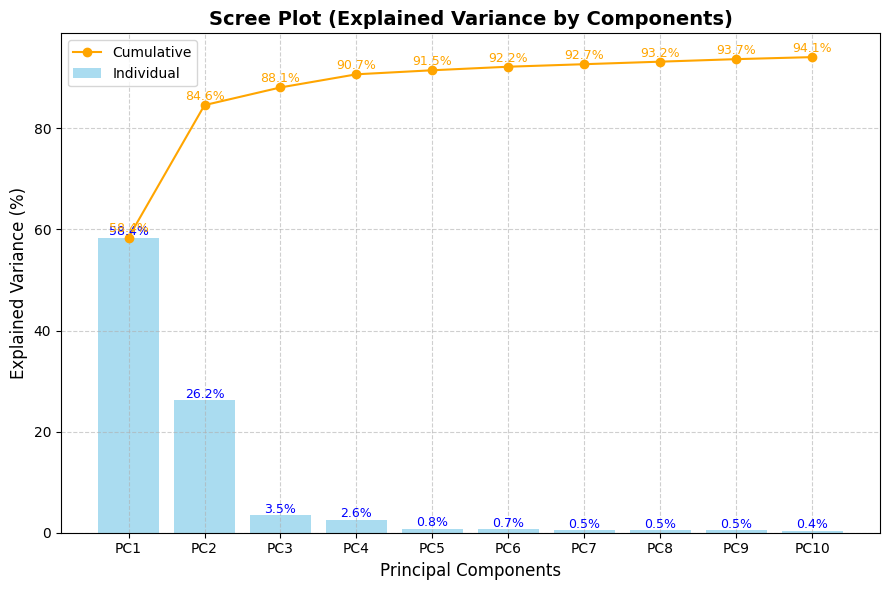

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have your PCA object (not just pca_4)
# Example: pca_all = PCA().fit(X_scaled)
per_var = np.round(pca_all.explained_variance_ratio_ * 100, decimals=1)
cum_var = np.cumsum(per_var)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

# --- Scree Plot with Cumulative Line ---
plt.figure(figsize=(9, 6))
plt.bar(range(1, len(per_var) + 1), per_var, alpha=0.7, color='skyblue', label='Individual')
plt.plot(range(1, len(per_var) + 1), cum_var, marker='o', color='orange', label='Cumulative')

plt.title('Scree Plot (Explained Variance by Components)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)
plt.xticks(range(1, len(per_var) + 1), labels)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate individual and cumulative values
for i, (ind, cum) in enumerate(zip(per_var, cum_var)):
    plt.text(i + 1, ind + 0.5, f'{ind}%', ha='center', fontsize=9, color='blue')
    plt.text(i + 1, cum + 1, f'{cum:.1f}%', ha='center', fontsize=9, color='orange')

plt.legend()
plt.tight_layout()
plt.savefig('scree_plot_all_components.png', dpi=450, bbox_inches='tight')
plt.show()


In [ ]:
per_var

array([58.4, 26.2,  3.5,  2.6,  0.8,  0.7,  0.5,  0.5,  0.5,  0.4])

In [ ]:
import numpy as np

# eigenvalues of each principal component
eigenvalues = pca_all.explained_variance_

print("Eigenvalues:\n", np.round(eigenvalues, 3))

# components with eigenvalue > 1
kaiser_components = np.where(eigenvalues > 1)[0] + 1  # +1 because index starts at 0

print(f"\nComponents satisfying Kaiser criterion (λ > 1): {kaiser_components}")
print(f"Number of components retained: {len(kaiser_components)}")


Eigenvalues:
 [137.329  61.568   8.347   6.093   1.903   1.64    1.227   1.15    1.059
   0.998]

Components satisfying Kaiser criterion (λ > 1): [1 2 3 4 5 6 7 8 9]
Number of components retained: 9


In [ ]:
for i, (eig, var) in enumerate(zip(eigenvalues, pca_all.explained_variance_ratio_ * 100), start=1):
    print(f"PC{i}: Eigenvalue={eig:.3f}, Explained Variance={var:.1f}%")


PC1: Eigenvalue=137.329, Explained Variance=58.4%
PC2: Eigenvalue=61.568, Explained Variance=26.2%
PC3: Eigenvalue=8.347, Explained Variance=3.5%
PC4: Eigenvalue=6.093, Explained Variance=2.6%
PC5: Eigenvalue=1.903, Explained Variance=0.8%
PC6: Eigenvalue=1.640, Explained Variance=0.7%
PC7: Eigenvalue=1.227, Explained Variance=0.5%
PC8: Eigenvalue=1.150, Explained Variance=0.5%
PC9: Eigenvalue=1.059, Explained Variance=0.5%
PC10: Eigenvalue=0.998, Explained Variance=0.4%


In [ ]:
## Principal Component Analysis

The first four principal components were analyzed to evaluate
spectral separability among socioeconomic classes.

#Applying PCA

In [ ]:
from sklearn.decomposition import PCA
pca_4 = PCA(n_components = 4)
X = pca_4.fit_transform(X)


In [ ]:
per_var = np.round(pca_4.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

In [ ]:
per_var

array([58.4, 26.2,  3.5,  2.6])


#Convert the transform data into dataframe


In [ ]:
pca_df = pd.DataFrame(X, index=None,columns=labels)

In [ ]:
print(pca_df)

           PC1       PC2       PC3       PC4
0    -4.427913  5.428621 -2.722947 -3.729965
1   -10.054534  0.131546 -1.141613 -3.944244
2     0.582697 -1.199653  3.106387 -2.713456
3    -5.485451 -6.021645  2.155279 -2.940473
4    -8.542979  2.706183 -1.096268 -4.186434
..         ...       ...       ...       ...
721 -11.546805  9.079123 -1.811796  2.261824
722  16.555673 -3.445452  1.236207  3.142476
723  20.330319 -1.830542 -0.837169  2.143377
724  12.333285 -4.876946 -1.105422 -0.605264
725  14.294411 -3.462949 -2.552407  1.821000

[726 rows x 4 columns]


In [ ]:
y_concate= pd.DataFrame(y,columns =['class'])

In [ ]:
print(y_concate)

     class
0        0
1        0
2        0
3        0
4        0
..     ...
721      1
722      1
723      1
724      1
725      1

[726 rows x 1 columns]


In [ ]:
vertical_concat = pd.concat([y_concate, pca_df], axis=1)

In [ ]:
vertical_concat

,class,PC1,PC2,PC3,PC4
0,0,-4.427913,5.428621,-2.722947,-3.729965
1,0,-10.054534,0.131546,-1.141613,-3.944244
2,0,0.582697,-1.199653,3.106387,-2.713456
3,0,-5.485451,-6.021645,2.155279,-2.940473
4,0,-8.542979,2.706183,-1.096268,-4.186434
...,...,...,...,...,...
721,1,-11.546805,9.079123,-1.811796,2.261824
722,1,16.555673,-3.445452,1.236207,3.142476
723,1,20.330319,-1.830542,-0.837169,2.143377
724,1,12.333285,-4.876946,-1.105422,-0.605264


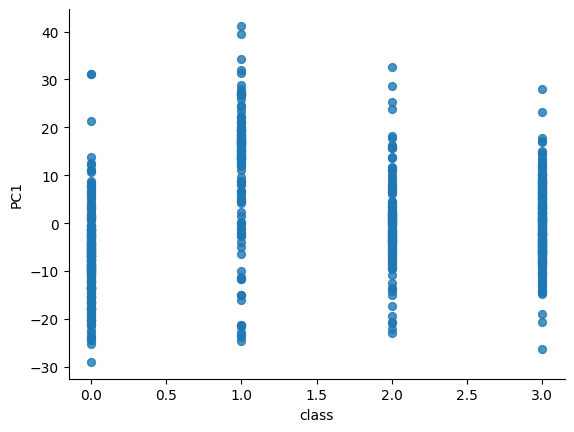

In [ ]:
from matplotlib import pyplot as plt
vertical_concat.plot(kind='scatter', x='class', y='PC1', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

fig = plt.figure()
ax_1 = sns.boxplot(x='class', y='PC1', data=vertical_concat)
ax_1 = sns.stripplot(x='class', y='PC1', data=vertical_concat)

plt.tight_layout()
plt.savefig("pc1_plot.png", dpi=500)
plt.close()


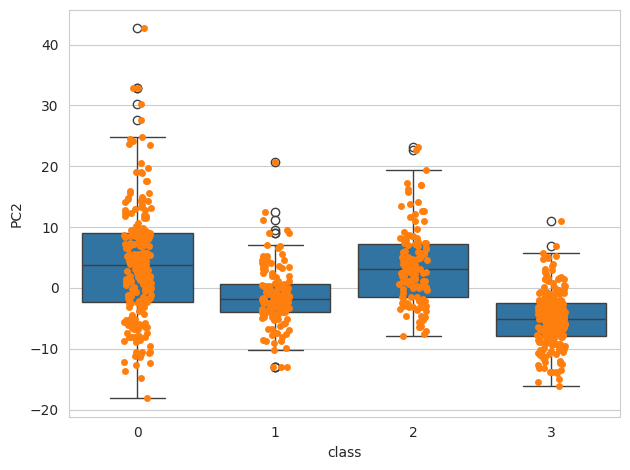

In [ ]:
sns.set_style('whitegrid')
ax_2 = sns.boxplot (x='class',y='PC2',data=vertical_concat)
ax_2 = sns.stripplot (x='class',y='PC2',data=vertical_concat)

plt.tight_layout()
plt.savefig("pc2_plot.png", dpi=500)
plt.show()

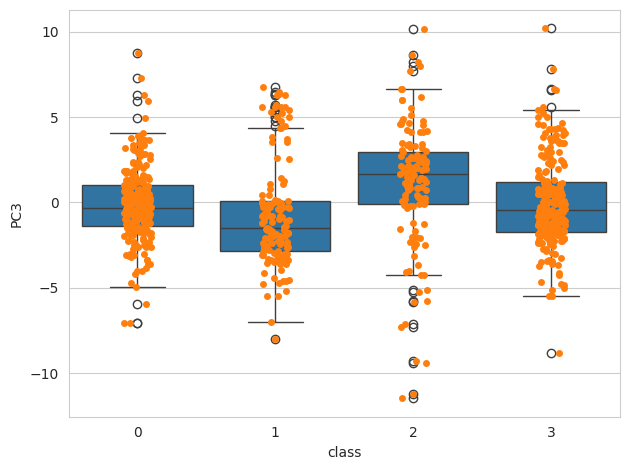

In [ ]:
sns.set_style('whitegrid')
ax_3 = sns.boxplot (x='class',y='PC3',data=vertical_concat)
ax_3 = sns.stripplot (x='class',y='PC3',data=vertical_concat)


plt.tight_layout()
plt.savefig("pc3_plot.png", dpi=500)
plt.show()

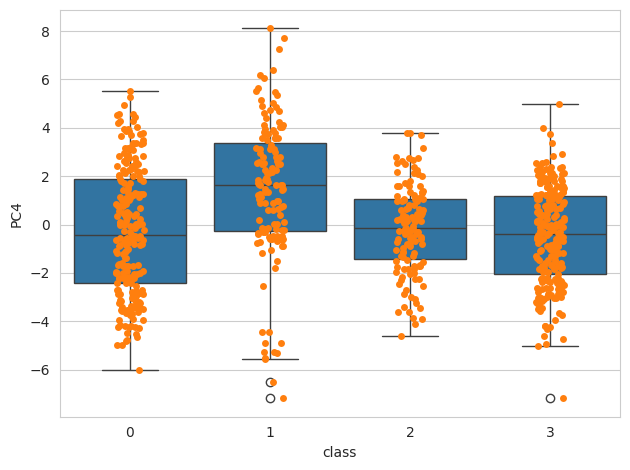

In [ ]:
sns.set_style('whitegrid')
ax_4 = sns.boxplot (x='class',y='PC4',data=vertical_concat)
ax_4 = sns.stripplot (x='class',y='PC4',data=vertical_concat)


plt.tight_layout()
plt.savefig("pc4_plot.png", dpi=500)
plt.show()

In [ ]:
from scipy.stats import ks_2samp
import itertools

# Classes in your dataset
classes = vertical_concat['class'].unique()

# Prepare to iterate over each principal component
pcs = ['PC1', 'PC2', 'PC3', 'PC4']

# Dictionary to hold the results
ks_results = {}

# Iterate over each principal component
for pc in pcs:
    ks_results[pc] = []
    # Generate all unique pairs of classes
    for class1, class2 in itertools.combinations(classes, 2):
        # Extract the data for these classes for the current principal component
        data_class1 = vertical_concat[vertical_concat['class'] == class1][pc]
        data_class2 = vertical_concat[vertical_concat['class'] == class2][pc]

        # Perform the KS test for this pair of classes
        ks_stat, p_value = ks_2samp(data_class1, data_class2)

        # Store the results
        ks_results[pc].append(((class1, class2), ks_stat, p_value))

# Optionally, print the results
for pc, results in ks_results.items():
    print(f"Results for {pc}:")
    for result in results:
        print(f"Classes {result[0][0]} vs {result[0][1]}: KS Statistic = {result[1]}, p-value = {result[2]}")
    print("\n")
#p-value is less than 0.05 conclude that the distributions are significantly different between the classes for that particular feature

Results for PC1:
Classes 0 vs 2: KS Statistic = 0.39369399269830735, p-value = 4.302434145246059e-12
Classes 0 vs 3: KS Statistic = 0.377558382380862, p-value = 2.990028122026314e-15
Classes 0 vs 1: KS Statistic = 0.6867647058823529, p-value = 3.540397974457293e-39
Classes 2 vs 3: KS Statistic = 0.11277042568085603, p-value = 0.2191930882637881
Classes 2 vs 1: KS Statistic = 0.5701616524472385, p-value = 1.3939058334313716e-20
Classes 3 vs 1: KS Statistic = 0.6020100179809915, p-value = 2.117062760218045e-29


Results for PC2:
Classes 0 vs 2: KS Statistic = 0.13893129770992366, p-value = 0.07072376835056624
Classes 0 vs 3: KS Statistic = 0.5560280994873742, p-value = 1.8050158252743322e-33
Classes 0 vs 1: KS Statistic = 0.3964833759590793, p-value = 1.5443646388750134e-12
Classes 2 vs 3: KS Statistic = 0.6105536851228375, p-value = 1.1767681541764159e-29
Classes 2 vs 1: KS Statistic = 0.41412213740458015, p-value = 8.736635764918224e-11
Classes 3 vs 1: KS Statistic = 0.3880041099409196

In [ ]:
# Assuming ks_results is your dictionary containing the results
# Let's transform this dictionary into a list of dictionaries for easier DataFrame conversion
records = []
for pc, results in ks_results.items():
    for result in results:
        records.append({
            'Principal Component': pc,
            'Class Pair': f"{result[0][0]} vs {result[0][1]}",
            'KS Statistic': result[1],
            'p-value': result[2]
        })

# Convert to DataFrame
results_df = pd.DataFrame(records)

# Pivot the DataFrame to have class pairs as rows and principal components as columns, showing p-values
pivot_df = results_df.pivot(index='Class Pair', columns='Principal Component', values='p-value')

# Display the pivot table
print(pivot_df)


Principal Component           PC1           PC2           PC3           PC4
Class Pair                                                                 
0 vs 1               3.540398e-39  1.544365e-12  1.807089e-06  1.183256e-07
0 vs 2               4.302434e-12  7.072377e-02  2.327172e-10  1.282291e-02
0 vs 3               2.990028e-15  1.805016e-33  3.724244e-01  4.308079e-03
2 vs 1               1.393906e-20  8.736636e-11  6.771355e-14  5.508605e-09
2 vs 3               2.191931e-01  1.176768e-29  1.813967e-09  2.304159e-01
3 vs 1               2.117063e-29  5.368362e-12  1.859619e-04  6.838753e-11


In [ ]:
# Highlight significant p-values with a color
def highlight_significance(val):
    color = 'salmon' if val < 0.05 else 'none'
    return f'background-color: {color}'

styled_pivot = pivot_df.style.applymap(highlight_significance)
styled_pivot

Principal Component,PC1,PC2,PC3,PC4
Class Pair,,,,
0 vs 1,0.000000,0.000000,0.000002,0.000000
0 vs 2,0.000000,0.070724,0.000000,0.012823
0 vs 3,0.000000,0.000000,0.372424,0.004308
2 vs 1,0.000000,0.000000,0.000000,0.000000
2 vs 3,0.219193,0.000000,0.000000,0.230416
3 vs 1,0.000000,0.000000,0.000186,0.000000


#Z-test

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats import weightstats as stests
from statsmodels.stats.weightstats import ztest

In [ ]:
built_up = vertical_concat[vertical_concat['Property']== 0]['PC5']
vegetation = vertical_concat[vertical_concat['Property']== 1]['PC5']
water = vertical_concat[vertical_concat['Property']== 2]['PC5']
f_score ,p_val = f_oneway(built_up,vegetation,water)
print('f-score:',f_score)
print('p-value:',p_val)

f-score: 34.711173969957876
p-value: 7.844067297257375e-15
